In [1]:
import os
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import f_oneway, kruskal

import stackview
from PIL import Image
from sklearn.metrics import r2_score, roc_curve, auc

from zod import ZodFrames
from zod.constants import AnnotationProject, Camera
from zod.visualization.object_visualization import overlay_object_2d_box_on_image

plt.style.use('default')
sns.set_palette("husl")
SEED = 43
np.random.seed(SEED)

# Load Data

In [2]:
base_data_path_file = "data_yolo_500e.csv"

iou_assessor_results = pd.read_csv("../results/assessors/iou_test_ass_" + base_data_path_file, index_col=0)
lrp_assessor_results = pd.read_csv("../results/assessors/lrp_test_ass_" + base_data_path_file, index_col=0)

print(iou_assessor_results.head(5))


     country time_of_day        lat       long       road_type road_condition  \
5425      SE         day  55.598791  12.984058            city         normal   
287       DE         day  50.955282   6.948882  arterial-urban         normal   
2813      SE         day  55.582589  13.011210            city         normal   
6835      SE         day  65.599415  22.137536  arterial-urban           snow   
8545      SE         day  55.594276  12.966245            city         normal   

                weather  solar_angle_elevation  month  hour  ...  \
5425  partly-cloudy-day              16.564819      5    17  ...   
287   partly-cloudy-day               6.266239     11     7  ...   
2813  partly-cloudy-day              39.813601      5    14  ...   
6835  partly-cloudy-day               3.741479      3    16  ...   
8545             cloudy              28.291068      5    15  ...   

      weather_code      conf        GT  baseline        lr        dt  \
5425           3.0  0.545829  0.

# Assessor Performance

In [3]:
def evaluate_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    errors = y_true - y_pred

    bin_size = 0.1
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    ece = 0.0
    N = len(y_pred)

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue

        bin_center = (bins[i - 1] + bins[i]) / 2.0
        median_obs = np.median(y_true[mask])
        ece += (mask.sum() / N) * abs(median_obs - bin_center)
        
    return {
        'r2': r2_score(y_true, y_pred),
        'mae': float(np.mean(np.abs(errors))),
        'mse': float(np.mean(errors ** 2)),
        "p95": np.quantile(np.abs(errors), 0.95),
        'ece': float(ece),              # Expected calibration error
    }


def record_regression_results(results, target, model_name, y_true, y_pred, split='test'):
    metrics = evaluate_regression_metrics(y_true, y_pred)
    split_label = split.capitalize()
    print(f"{split_label} R2 score {metrics['r2']:.4f}")
    print(f"{split_label} MAE score {metrics['mae']:.4f}")
    print(f"{split_label} MSE score {metrics['mse']:.4f}")
    print(f"{split_label} P95 score {metrics['p95']:.4f}")
    print(f"{split_label} ECE score {metrics['ece']:.4f}")
    results.append({
        'target': target,
        'model': model_name,
        f'{split}_r2': metrics['r2'],
        f'{split}_mae': metrics['mae'],
        #f'{split}_mse': metrics['mse'],
        #f'{split}_p95': metrics['p95'],
        f'{split}_ece': metrics['ece'],
    })
    return metrics

## IoU

In [4]:
model_cols = ["baseline", "lr", "dt", "rf", "mlp", "xgb", "autg"]

In [5]:
iou_metrics_rows = []
for model in model_cols:
    metrics = evaluate_regression_metrics(iou_assessor_results["GT"], iou_assessor_results[model])
    iou_metrics_rows.append({"model": model, **metrics})

iou_metrics = pd.DataFrame(iou_metrics_rows).sort_values("r2", ascending=False)
display(iou_metrics)


,model,r2,mae,mse,p95,ece
6,autg,0.386160,0.097025,0.016731,0.268115,0.009835
3,rf,0.377166,0.096889,0.016976,0.268752,0.006781
1,lr,0.367875,0.098397,0.017229,0.275519,0.015391
5,xgb,0.361849,0.099704,0.017393,0.276447,0.007397
0,baseline,0.349276,0.099593,0.017736,0.288802,0.013745
2,dt,0.342476,0.099661,0.017921,0.278696,0.012527
4,mlp,0.327914,0.102253,0.018318,0.281602,0.017786


## LRP

In [6]:
lrp_metrics_rows = []
for model in model_cols:
    metrics = evaluate_regression_metrics(lrp_assessor_results["GT"], lrp_assessor_results[model])
    lrp_metrics_rows.append({"model": model, **metrics})

lrp_metrics = pd.DataFrame(lrp_metrics_rows).sort_values("r2", ascending=False)
display(lrp_metrics)


,model,r2,mae,mse,p95,ece
3,rf,0.432915,0.077167,0.011692,0.229527,0.010422
6,autg,0.432184,0.077383,0.011707,0.229024,0.013139
1,lr,0.420760,0.080159,0.011942,0.230318,0.007703
5,xgb,0.412973,0.079430,0.012103,0.228397,0.007688
2,dt,0.410753,0.078499,0.012149,0.229439,0.015306
4,mlp,0.405183,0.080519,0.012264,0.234819,0.013816
0,baseline,0.394619,0.082197,0.012481,0.231379,0.010010


# Error analysis

In [30]:
THRESHOLD = 0.5   # Delta between predicte and expected value
TARGET_MODEL = "autg"

## IoU

In [31]:

error_df = iou_assessor_results.copy()
error_df[f"abs_delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL]).abs()
error_df[f"delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL])
high_error = error_df[error_df[f"abs_delta_{TARGET_MODEL}"] > THRESHOLD]

print(f"High-error instances (|GT - {TARGET_MODEL}| > {THRESHOLD}): {len(high_error)}")
display(high_error[["GT", TARGET_MODEL, f"abs_delta_{TARGET_MODEL}", f"delta_{TARGET_MODEL}"]].head(10))

High-error instances (|GT - autg| > 0.5): 7


,GT,autg,abs_delta_autg,delta_autg
2018,0.916746,0.272873,0.643873,0.643873
2919,0.130215,0.639965,0.509750,-0.509750
1404,0.111562,0.656285,0.544722,-0.544722
8906,0.127482,0.633893,0.506411,-0.506411
3199,0.226373,0.736198,0.509824,-0.509824
6840,0.870656,0.368845,0.501810,0.501810
6329,0.784220,0.259187,0.525033,0.525033


In [32]:
dataset_root = "../data/zod"
version = "full" 
zod_frames = ZodFrames(dataset_root=dataset_root, version=version)

imgs_good_gt = []
id_good_gt = []
imgs_bad_gt = []
id_bad_gt = []
missing = []
for frame_id in high_error.index:
    zod_frame = zod_frames[frame_id]
    image = zod_frame.get_image() 
    annotations = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)
    annotations_2d = [annotation.box2d for annotation in annotations]

    for ann in annotations_2d:
        image_with_boxes = overlay_object_2d_box_on_image(image,ann, color=(255, 0, 0), line_thickness=10)

    if image_with_boxes is None:
        missing.append(frame_id)

    if high_error.loc[frame_id][f"delta_{TARGET_MODEL}"] > 0:
        imgs_good_gt.append(image_with_boxes)
        id_good_gt.append(frame_id)
    else: 
        imgs_bad_gt.append(image_with_boxes)
        id_bad_gt.append(frame_id)

Loading infos: 0it [00:00, ?it/s]

In [33]:
print(f"Number of images: {len(imgs_good_gt) + len(imgs_bad_gt)} with id {high_error.index}")
print(f"Missing images: {len(missing)} with ids: {sorted(missing)}")

Number of images: 7 with id Index([2018, 2919, 1404, 8906, 3199, 6840, 6329], dtype='int64')
Missing images: 0 with ids: []


Images where object detection system worked well, but assessor predicted it will not

In [34]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_good_gt], imgs_good_gt))
stackview.switch(stack)

In [36]:
display(iou_assessor_results.loc[id_good_gt])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,weather_code,conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
2018,SE,day,62.963308,17.183167,smaller-rural,snow,snow,7.171734,1,11,...,73.0,0.263572,0.916746,0.193245,0.259257,0.010008,0.072130,0.212784,0.061416,0.272873
6840,IT,night,41.831484,12.386284,highway,normal,clear-night,-27.045748,8,21,...,0.0,0.794025,0.870656,0.548198,0.517765,0.422100,0.462211,0.547664,0.419378,0.368845
6329,PL,day,52.185882,22.932099,smaller-rural,normal,clear-day,44.563592,4,8,...,0.0,0.388250,0.784220,0.276674,0.266803,0.269352,0.293655,0.322893,0.300725,0.259187


Images where object detection system did not worked well, but assessor predicted it will

In [35]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_bad_gt], imgs_bad_gt))
stackview.switch(stack)

In [37]:
display(iou_assessor_results.loc[id_bad_gt])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,weather_code,conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
2919,SE,day,62.448254,17.337278,arterial-urban,snow,snow,7.787783,1,10,...,75.0,0.864967,0.130215,0.595669,0.679012,0.660856,0.643590,0.615080,0.566464,0.639965
1404,SE,twilight,67.133496,20.671417,arterial-rural,snow,partly-cloudy-night,-1.381125,1,8,...,1.0,0.897473,0.111562,0.617420,0.677261,0.660856,0.663499,0.553086,0.653891,0.656285
8906,SE,day,63.699394,20.035110,arterial-rural,wet,snow,8.480371,3,15,...,73.0,0.873773,0.127482,0.601561,0.643580,0.660856,0.639953,0.513876,0.635517,0.633893
3199,NO,day,64.060957,11.494575,arterial-rural,snow,partly-cloudy-day,10.577054,2,9,...,3.0,0.884979,0.226373,0.609060,0.618862,0.660856,0.695075,0.612703,0.650256,0.736198


# Regression Reliability Plots

Calibration curves but for regression. 

In [15]:
def plot_calibration_curve(y_true, y_pred, bin_size=0.1, ax=None, label=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    avg_predicted = []
    avg_observed = []
    err_low = []
    err_high = []
    rng = np.random.default_rng(0)
    alpha = (1.0 - 0.95) / 2.0    #95% CI

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue
        avg_predicted.append((bins[i - 1] + bins[i]) / 2)  # Center of bin, so it is not influenced by the data
        avg_observed.append(float(np.median(y_true[mask])))   # Mean of observed IoU

        if 300 > 0: #Bootstrap CI
            boots = np.empty(300)
            n = y_true[mask].size
            for b in range(300):
                boots[b] = np.median(rng.choice(y_true[mask], size=n, replace=True))
            lo = np.quantile(boots, alpha)
            hi = np.quantile(boots, 1.0 - alpha)
            #err_low.append(float(np.median(y_true[mask])) - lo)
            err_low.append(lo)
            #err_high.append(hi - float(np.median(y_true[mask])))
            err_high.append(hi)
        else:
            err_low.append(np.nan)
            err_high.append(np.nan)
    
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Perfect')
    ax.plot(avg_predicted, avg_observed, marker='o', label=label or 'Model')
    ax.fill_between(avg_predicted, err_low, err_high, alpha=0.15)
    #ax.errorbar(avg_predicted,avg_observed,yerr=np.vstack([err_low, err_high]),fmt='o-',capsize=3,label=label or 'Model')
    ax.set_xlabel('Predicted IoU (bin center)')
    ax.set_ylabel('Observed IoU (median)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    if label is not None:
        ax.legend()
    return ax


def plot_inst_per_bin(y_pred, bin_size=0.1, ax=None, label=None):
    y_pred = np.asarray(y_pred)
    
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    n_instances = []
    bin_centers = [] 
    for i in range(1, len(bins)):
        mask = bin_ids == i
        n = np.count_nonzero(mask)
        n_instances.append(n)
        bin_centers.append((bins[i - 1] + bins[i]) / 2)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.bar(bin_centers, height=n_instances, width=bin_size, label=label or 'Model')
    ax.set_xlabel('Bins')
    ax.set_ylabel('Nº of instances')
    if label is not None:
        ax.legend()
    return ax

## IoU

<Axes: xlabel='Bins', ylabel='Nº of instances'>

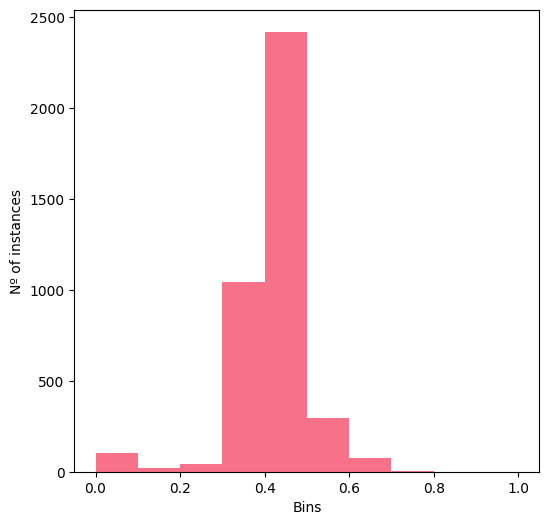

In [16]:
plot_inst_per_bin(iou_assessor_results["xgb"])

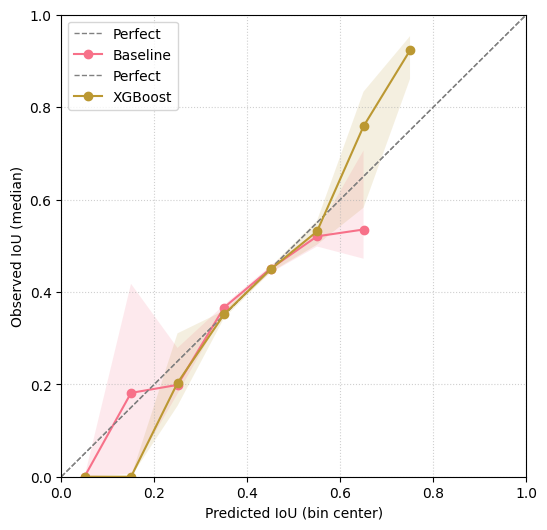

In [40]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_calibration_curve(iou_assessor_results["GT"], iou_assessor_results["baseline"], ax=ax, label="Baseline")
plot_calibration_curve(iou_assessor_results["GT"], iou_assessor_results["xgb"], ax=ax, label="XGBoost")
#plot_calibration_curve(y_test, y_pred_iou_rf, ax=ax, label="RanfomForest")
ax.legend()
plt.savefig("./plots/iou_baseline_vs_xgb_calib_curve.png")

## LRP

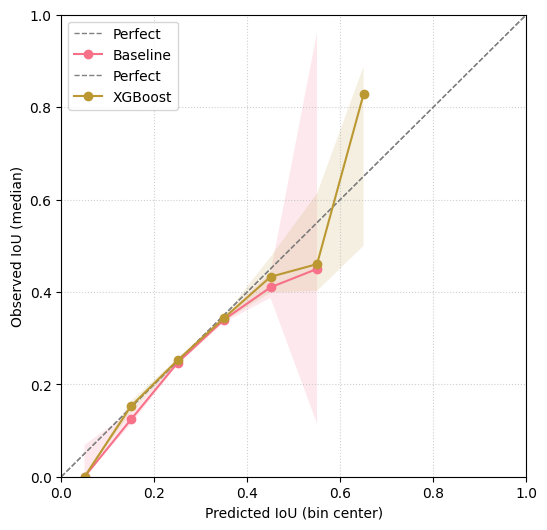

In [39]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_calibration_curve(lrp_assessor_results["GT"], lrp_assessor_results["baseline"], ax=ax, label="Baseline")
plot_calibration_curve(lrp_assessor_results["GT"], lrp_assessor_results["xgb"], ax=ax, label="XGBoost")
ax.legend()
plt.savefig("./plots/lrp_baseline_vs_xgb_calib_curve.png")

# AUROC

For the AUROC we need to discretize the task to binary by setting a treshold. This is not ideal as we are deleting information. So not very useful. 

In [19]:
def plot_auroc(y_true_iou, y_pred, threshold=0.5, ax=None, label=None):
    y_true_iou = np.asarray(y_true_iou)
    y_pred = np.asarray(y_pred)
    success = (y_true_iou > threshold).astype(int)

    fpr, tpr, _ = roc_curve(success, y_pred)
    roc_auc = auc(fpr, tpr)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random')
    ax.plot(fpr, tpr, label=label or f'AUROC = {roc_auc:.3f}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    return ax, roc_auc

## IoU

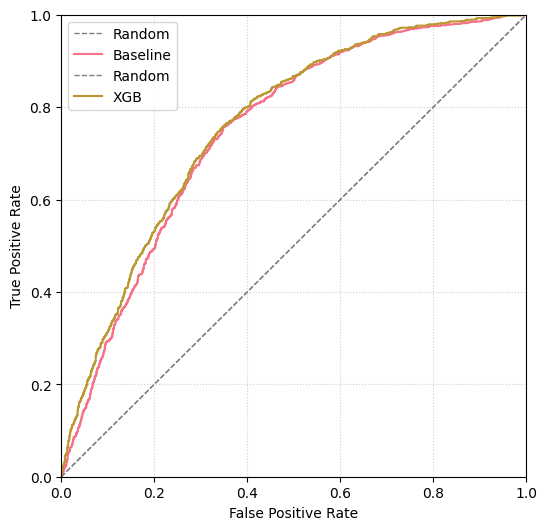

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["baseline"], threshold=0.5, ax=ax, label="Baseline")
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["xgb"], threshold=0.5, ax=ax, label="XGB")
ax.legend()